#Actividad 1

El objetivo de esta actividad es encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la regresión lineal para intentar predecirla a partir de las demás variables predictoras.

El método que seguiremos es el siguiente:

●      Preparación y organización de datos

●      Exploración de los datos

●      Modelado de datos

##*Preparación y Organización de Datos*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Preparación y Organización de Datos
# Cargar Dataset y mostrar primeras 5 filas
url = '/content/drive/MyDrive/Aprendizaje Automático/Archivos semana 4/student-mat.csv'
df = pd.read_csv(url, sep=";")

# Seleccionar variables para predecir nota final
# Variable Objetivo: G3 (Nota final)
# Variables Predictoras: age, studytime, failures, absences, G1, G2
# Para este modelo simple, elegiremos variables numéricas directas
features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['G3']

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


##*Exploración de los Datos*

In [2]:
# Exploración Inicial (EDA)
print("\nDescripción del DataFrame:")
df.describe()
print("\nInformación del DataFrame:")
df.info()
df.isnull().sum()



Descripción del DataFrame:

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


El dataset 'Student Performance' del repositorio UCI contiene registros de estudiantes que incluye 30 variables, demográficas, familiares, sociales y académicas. El objetivo es analizar y predecir el rendimiento escolar, especialmente la nota final (G3), variable continua.

Las variables contienen información personal (edad, sexo, domicilio), contexto familiar (educación y ocupación de los padres), hábitos de estudio (tiempo de estudio, ausencias, apoyo escolar) hasta calificaciones previas (G1 y G2).

In [3]:
print("Descripción estadística:")
print(df.describe())

Descripción estadística:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
st

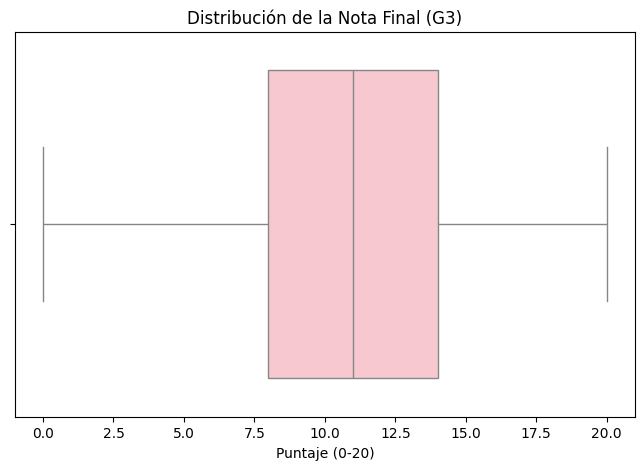

In [4]:
# Boxplot de la Variable Objetivo (G3)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['G3'], color='pink')
plt.title('Distribución de la Nota Final (G3)')
plt.xlabel('Puntaje (0-20)')
plt.show()

1. La Variable Objetivo: G3 (Nota Final)

El Rango: Las notas van de 0 a 20.

La Media: El promedio es 10.41, lo que nos dice que el grupo está apenas por encima de la mitad del puntaje máximo.

El Problema de los Ceros: El mínimo es 0.00. Como la nota mínima en G1 es 3, ese 0 en la nota final puede indicar alumnos que abandonaron o no rindieron.

2. Calificaciones Previas: G1 y G2

Tienen medias (10.9 y 10.7) y desviaciones estándar muy similares a G3.

Esto sugiere que existe una fuerte consistencia. Si un alumno sacó 11 en G1, es muy probable que saque algo cercano en G3.

3. Las Ausencias (absences)

Hay una diferencia entre la media (5.7) y el máximo (75).

La desviación estándar es 8.0, más alta que la media. Esto indica que los datos están muy dispersos: la mayoría falta poco, pero hay unos pocos alumnos ("outliers") que faltan muchísimo.

4. Hábitos de Estudio (studytime)

La media es 2.03. En este dataset, el valor 2 significa entre 2 y 5 horas de estudio semanales.Al tener un máximo de 4 y un mínimo de 1, es una variable con poca dispersión. Puede servir para ver si hay una variación en la nota.

Detección de Atípicos (Outliers): Graficando un boxplot de las ausencias (absences), se puede ver si hay alumnos con demasiadas faltas que distorsionen el promedio.

In [5]:
df.corr(numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


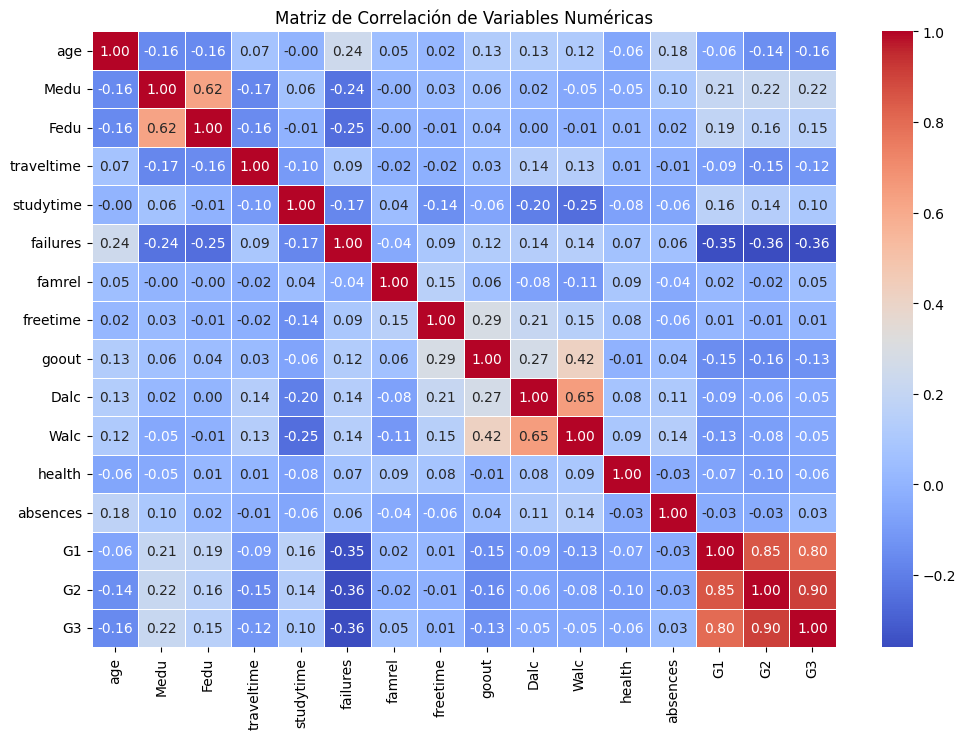

In [6]:
# 2. Matriz de Correlación
plt.figure(figsize=(12, 8))
# Seleccionamos solo columnas numéricas
df_numeric = df.select_dtypes(include=['number'])
correlation = df_numeric.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

En el análisis de Correlación, se puede ver que G1 y G2 tienen una correlación muy fuerte (0.8 y 0.9) con G3.

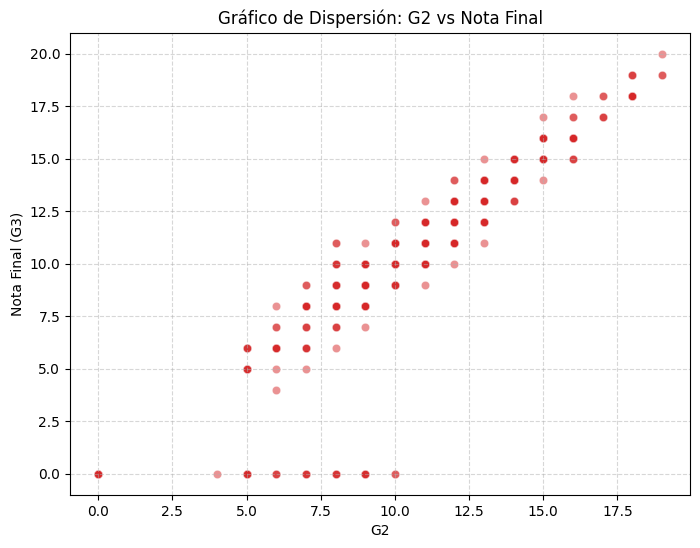

In [7]:
# Gráfico de Dispersión: G2 vs G3
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='G2', y='G3', color='#d62728', alpha=0.5)
plt.title('Gráfico de Dispersión: G2 vs Nota Final')
plt.xlabel('G2')
plt.ylabel('Nota Final (G3)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##*Luego de analizar el Dataset, elijo G2 para mi modelo de Regresión Lineal.*

In [8]:
X_simple = df[['G2']]
y = df['G3']

# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Modelado
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


##Evaluación del modelo

In [9]:
# Predicciones
y_pred = model_simple.predict(X_test)

# Métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 4.216183766505532
R²: 0.794383123755501


MSE (Error cuadrático medio): mide el error promedio del modelo.

R²: indica qué tan bien el modelo explica la variabilidad de los datos (cercano a 1 = mejor).

In [10]:
# Intercepto y Coeficiente
print("Intercepto:", model_simple.intercept_)
print("Coeficiente:", model_simple.coef_)
# Evaluación
print("\nEvaluación del modelo (Regresión Simple):")
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("MSE:", mean_squared_error(y_test, y_pred_simple))
print("R²:", r2_score(y_test, y_pred_simple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_simple))


Intercepto: -1.4936733199830226
Coeficiente: [1.1096259]

Evaluación del modelo (Regresión Simple):
MAE: 1.2086747008196355
MSE: 4.216183766505532
R²: 0.794383123755501
Varianza explicada: 0.7948912877727268


Análisis de la Ecuación del Modelo

Según mis resultados (Intercepto $\approx -1.49$ y Coeficiente $\approx 1.11$), la ecuación de tu modelo es:$$G3 = -1.49 + 1.11 \times G2$$

Esto significa que:

*Pendiente (1.11)*, por cada punto que un alumno sube en su segunda nota (G2), se espera que su nota final (G3) aumente 1.11 puntos.

*Intercepto (-1.49)*: Teóricamente, si un alumno saca 0 en G2, su nota final sería negativa. Esto refuerza que el modelo es más preciso en el rango central de notas que en los extremos.

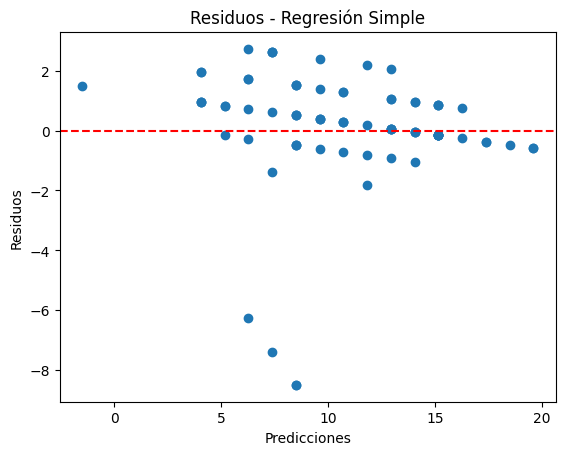

In [11]:
# Residuos
residuos = y_test - y_pred_simple
plt.scatter(y_pred_simple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Simple")
plt.show()

Evaluación del Rendimiento

Las métricas de evaluación son sólidas para un modelo inicial:

R^2 = 0.794: Esto es muy alto. Significa que el 79.4% de la variación en la nota final de los alumnos puede explicarse únicamente conociendo su nota en G2.

MAE = 1.20: En promedio, las predicciones se equivocan por poco más de un punto (en una escala de 0 a 20). Es un margen de error bastante aceptable para decisiones académicas.

Gráfico de Residuos: Si los puntos en este gráfico están dispersos al azar alrededor de la línea roja, el modelo es saludable. Si se ven patrones (como una forma de embudo), indicaría que el error aumenta en notas altas o bajas.

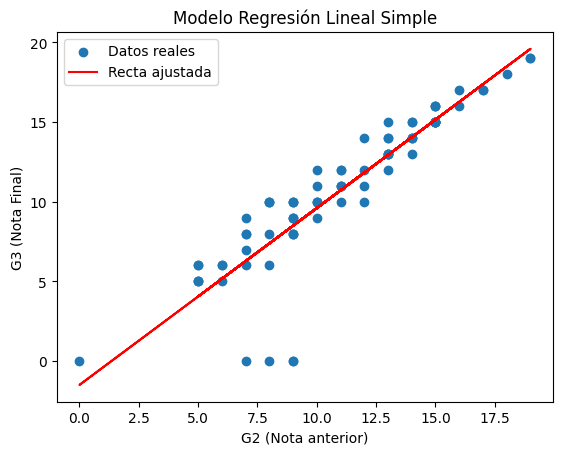

In [12]:
# Gráfico de la recta
plt.scatter(X_test, y_test, label="Datos reales")
plt.plot(X_test, y_pred_simple, color='red', label="Recta ajustada")
plt.xlabel("G2 (Nota anterior)")
plt.ylabel("G3 (Nota Final)")
plt.legend()
plt.title("Modelo Regresión Lineal Simple")
plt.show()

*El modelo utiliza la variable 'G2' (Nota anterior), para predecir 'G3'.*
*El coeficiente indica cuánto aumenta la nota final por cada punto adicional en G2.*
*El gráfico muestra una regresión lineal positiva entre ambas variables, confirmando lo analizado previamente.*
*El R² indica qué tan bien G2 explica lña variabilidad de G3.*

#Actividad 2

Te proponemos entonces que realices ahora la siguiente actividad con los conceptos leídos anteriormente.

Para esta actividad se ha creado un archivo *usuarios_win_mac_lin.csv* con datos de entrada a modo de ejemplo para clasificar si el usuario que visita un sitio web usa como sistema operativo Windows, Macintosh o Linux.

Nuestra información de entrada son 4 características que se tomó de una web que utiliza Google Analytics y son:

●      Duración de la visita en Segundos

●      Cantidad de Páginas Vistas durante la Sesión

●      Cantidad de Acciones del usuario (click, scroll, uso de checkbox, sliders,etc)

●      Suma del Valor de las acciones (cada acción lleva asociada una valoración de importancia)

Como la salida es discreta, asignaremos los siguientes valores a las etiquetas:

0 – Windows

1 – Macintosh

2 -Linux

Tu tarea es crear una Jupyter Notebook Regresion_logistica.ipynb que permita predecir qué sistema operativo utiliza un usuario según los datos de entrada.

¿Cómo pudiste llevar adelante esta actividad? te pareció muy difícil o muy fácil?  ¿por qué?  Por favor compartí tu respuesta en el foro del Campus

#*DESARROLLO*

In [13]:
# Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
# Carga de Datos
df = pd.read_csv("/content/drive/MyDrive/Aprendizaje Automático/Archivos semana 4/usuarios_win_mac_lin.csv")
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [15]:
df.columns

Index(['duracion', 'paginas', 'acciones', 'valor', 'clase'], dtype='object')

In [16]:
# Separar variables

# Variables predictoras (X)
X = df[['duracion', 'paginas', 'acciones', 'valor']]

# Variable objetivo (y)
y = df['clase']

In [17]:
# Dividir en entrenamiento y prueba (80% para entrenar y 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Crear y entrenar el modelo
modelo = LogisticRegression(max_iter=1000, solver='lbfgs')
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
# Hacer predicciones
y_pred = modelo.predict(X_test)

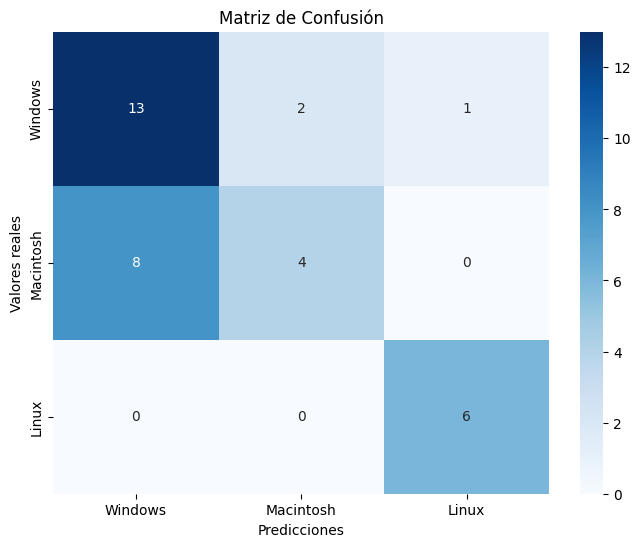

Matriz de confusión:
[[13  2  1]
 [ 8  4  0]
 [ 0  0  6]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



In [20]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Windows', 'Macintosh', 'Linux'],
            yticklabels=['Windows', 'Macintosh', 'Linux'])

plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.show()

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

**Desarrollo**:

*Para este ejercicio, se utilizó un modelo de regresión logística multinominal*

*El objetivo: predecir qué sistema operativo utiliza un usuario según los datos de entrada.*

*El modelo fue evaluado mediante una matriz de confusión y un reporte de clasificación.*

**Interpretación:**

Segun la matriz de confusión:

Windows, 13 bien clasificados y 3 errores (2 como Mac y 1 como Linux).

Mac, 4 bien clasificados y 8 fueron confundidos como windows.

Linux, 6 de 6. Perfecto.

Esto nos dice que el modelo funciona bien con Linux; aceptable con Windows y tiene problemas con Mac.

Segun el reporte de clasificación:

accuracy = 0.68 -> El modelo acierta el 68 % de los casos.

Windows -> Precisión 0.62, Recall 0.81 (Detecta bien windows, pero se confunde bastante).

Mac -> Precisión 0.67, Recall 0.33 (Solo detecta el 33% de los Mac reales, la mayoría los clasifica como windows).

Linux -> Precisión 0.86, Recall 1.00 (Detecta todos los Linux y casi no se equivoca).


##Conclusión:

El modelo obtuvo una precisión general del 68%, podría ser un desempeño aceptable.

La matriz de confusión nos muestra que Linux tiene una clasificación perfecta, sin errores. La clase Windows, muestra un buen nivel de acierto, aunque con confusiones menores.

En cambio, la clase Mac muestra un desempeño bajo, con un recal del 0.33, lo que nos dice que el modelo tiene problemas para identificar a estos usuarios, confundiéndolos mayormente con Windows.

